# UNSW-NB15 Dataset — Exploratory Data Analysis & IDS Baseline

**Dataset:** UNSW-NB15 (Australian Centre for Cyber Security)  
**Reference Paper:** *Optimized Ensemble Deep Learning for Real-Time Intrusion Detection on Resource-Constrained Raspberry Pi Devices* — Musthafa et al., IEEE Access 2025  
**Purpose:** EDA, preprocessing, ANOVA feature selection, and baseline ML/DL modelling pipeline for binary intrusion detection  

---
**Sections:**
1. Setup & Data Loading
2. Dataset Overview (shape, dtypes, missing values)
3. Class Distribution Analysis
4. Attack Category Deep-Dive
5. Feature Statistics & Correlation
6. Protocol / Service / State Analysis
7. Distribution Plots — Key Features
8. Preprocessing (Encoding, Scaling)
9. ANOVA Feature Selection (paper-aligned)
10. PCA Visualisation
11. Random Forest Baseline + Feature Importances
12. Stacked LSTM Binary Classifier (PyTorch)
13. Evaluation & Summary
---

## 1. Setup & Data Loading

In [14]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import f_classif          # ANOVA F-test
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [15]:
# ── Adjust these paths to match your folder structure ──────────────────────
BASE_DIR = os.getcwd()
TRAIN_PATH = os.path.join(BASE_DIR, 'data', 'UNSW_NB15', 'UNSW_NB15_training-set.csv')
TEST_PATH  = os.path.join(BASE_DIR, 'data', 'UNSW_NB15', 'UNSW_NB15_testing-set.csv')
FEAT_PATH  = os.path.join(BASE_DIR, 'data', 'UNSW_NB15', 'UNSW_NB15_features.csv')
# ────────────────────────────────────────────────────────────────────────────

print('Checking files:')
for label, path in [('Train', TRAIN_PATH), ('Test', TEST_PATH), ('Features', FEAT_PATH)]:
    print(f'  {label:8s}: {os.path.exists(path)} → {path}')

Checking files:
  Train   : True → d:\IDS-Internship-Project\data\UNSW_NB15\UNSW_NB15_training-set.csv
  Test    : True → d:\IDS-Internship-Project\data\UNSW_NB15\UNSW_NB15_testing-set.csv
  Features: True → d:\IDS-Internship-Project\data\UNSW_NB15\UNSW_NB15_features.csv


In [16]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)
feat_df = pd.read_csv(FEAT_PATH, encoding='latin-1')

# Note: the official split has train=82,332 and test=175,341
print(f'Train : {train_df.shape}')
print(f'Test  : {test_df.shape}')
print(f'Features  : {feat_df.shape}')

Train : (82332, 45)
Test  : (175341, 45)
Features  : (49, 4)


## 2. Dataset Overview

In [17]:
train_df.head(10)

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.09020,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.00030,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.00510,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.66080,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.00250,...,1,3,0,0,0,2,3,0,Normal,0
5,6,0.000003,udp,-,INT,2,0,784,0,333333.32150,...,1,2,0,0,0,2,2,0,Normal,0
6,7,0.000006,udp,-,INT,2,0,1960,0,166666.66080,...,1,2,0,0,0,2,2,0,Normal,0
7,8,0.000028,udp,-,INT,2,0,1384,0,35714.28522,...,1,3,0,0,0,1,3,0,Normal,0
8,9,0.000000,arp,-,INT,1,0,46,0,0.00000,...,2,2,0,0,0,2,2,1,Normal,0
9,10,0.000000,arp,-,INT,1,0,46,0,0.00000,...,2,2,0,0,0,2,2,1,Normal,0


In [18]:
print('=== dtypes ===')
print(train_df.dtypes)
print()
print('=== Missing values (train) ===')
miss = train_df.isnull().sum()
print(miss[miss > 0] if miss.any() else 'No missing values ✓')

=== dtypes ===
id                     int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64

In [19]:
train_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,82332.0,NaN,NaN,NaN,41166.5,23767.345519,1.0,20583.75,41166.5,61749.25,82332.0
dur,82332.0,NaN,NaN,NaN,1.006756,4.710444,0.0,0.000008,0.014138,0.71936,59.999989
proto,82332,131,tcp,43095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,82332,13,-,47153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,82332,7,FIN,39339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spkts,82332.0,NaN,NaN,NaN,18.666472,133.916353,1.0,2.0,6.0,12.0,10646.0
dpkts,82332.0,NaN,NaN,NaN,17.545936,115.574086,0.0,0.0,2.0,10.0,11018.0
sbytes,82332.0,NaN,NaN,NaN,7993.908165,171642.26188,24.0,114.0,534.0,1280.0,14355774.0
dbytes,82332.0,NaN,NaN,NaN,13233.785563,151471.456091,0.0,0.0,178.0,956.0,14657531.0
rate,82332.0,NaN,NaN,NaN,82410.886739,148620.367041,0.0,28.606114,2650.176667,111111.1072,1000000.003


In [20]:
feat_df = pd.read_csv(FEAT_PATH, encoding='latin-1')
print(feat_df.columns.tolist())
feat_df.columns = feat_df.columns.str.strip()
print(feat_df.columns.tolist())

['No.', 'Name', 'Type ', 'Description']
['No.', 'Name', 'Type', 'Description']


In [21]:
# Feature description from the official UNSW-NB15 feature document
feat_df[['No.', 'Name', 'Type', 'Description']]

,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


## 3. Class Distribution Analysis
Binary label: `0 = Normal`, `1 = Attack`

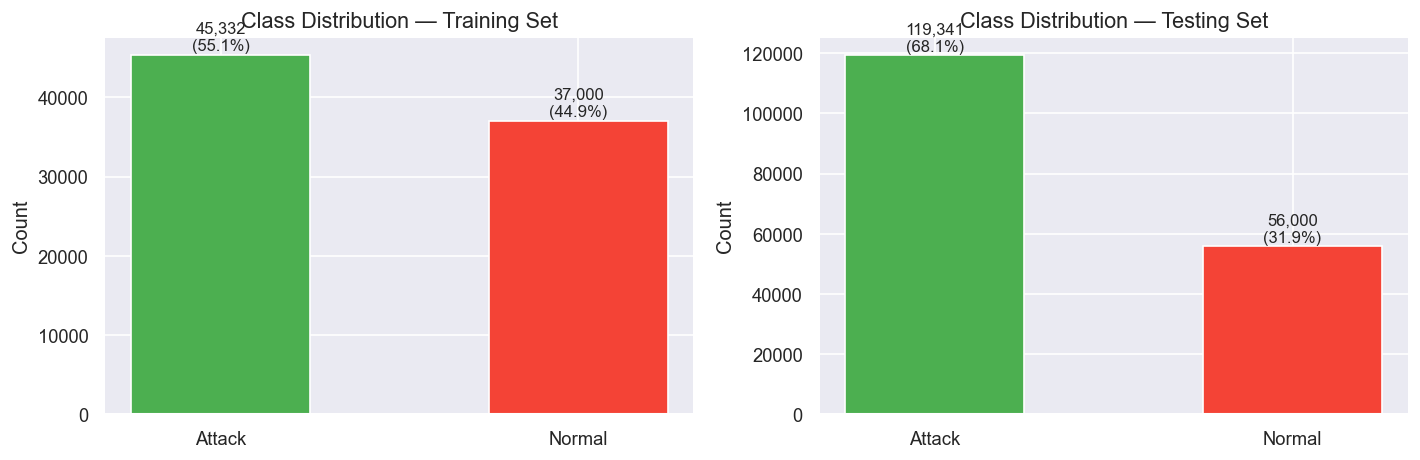

Train label distribution:
 label
1    45332
0    37000
Name: count, dtype: int64

Test label distribution:
 label
1    119341
0     56000
Name: count, dtype: int64


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes, [train_df, test_df], ['Training Set', 'Testing Set']):
    counts = df['label'].map({0: 'Normal', 1: 'Attack'}).value_counts()
    colors = ['#4CAF50', '#F44336']
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
    ax.set_title(f'Class Distribution — {title}')
    ax.set_ylabel('Count')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 200,
                f'{h:,}\n({h/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print('Train label distribution:\n', train_df['label'].value_counts())
print('\nTest label distribution:\n', test_df['label'].value_counts())

## 4. Attack Category Deep-Dive
UNSW-NB15 has **9 attack categories**: Fuzzers, Analysis, Backdoors, DoS, Exploits, Generic, Reconnaissance, Shellcode, Worms

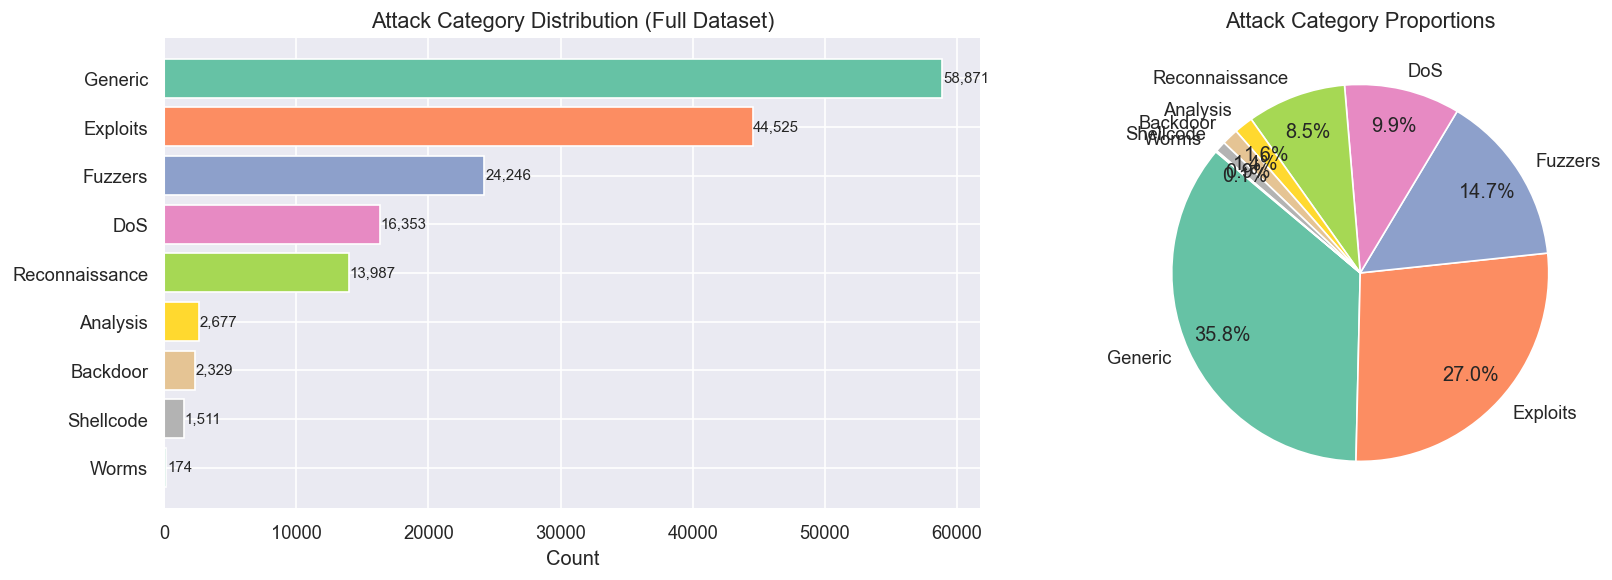

attack_cat
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64


In [23]:
# Combine train + test for full picture
full_df = pd.concat([train_df, test_df], ignore_index=True)

attack_counts = (
    full_df[full_df['label'] == 1]['attack_cat']
    .str.strip()
    .value_counts()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
palette = sns.color_palette('Set2', len(attack_counts))
axes[0].barh(attack_counts.index[::-1], attack_counts.values[::-1],
             color=palette[::-1], edgecolor='white')
axes[0].set_title('Attack Category Distribution (Full Dataset)')
axes[0].set_xlabel('Count')
for i, v in enumerate(attack_counts.values[::-1]):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# Pie chart
axes[1].pie(attack_counts, labels=attack_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=palette, pctdistance=0.8)
axes[1].set_title('Attack Category Proportions')

plt.tight_layout()
plt.show()

print(attack_counts)

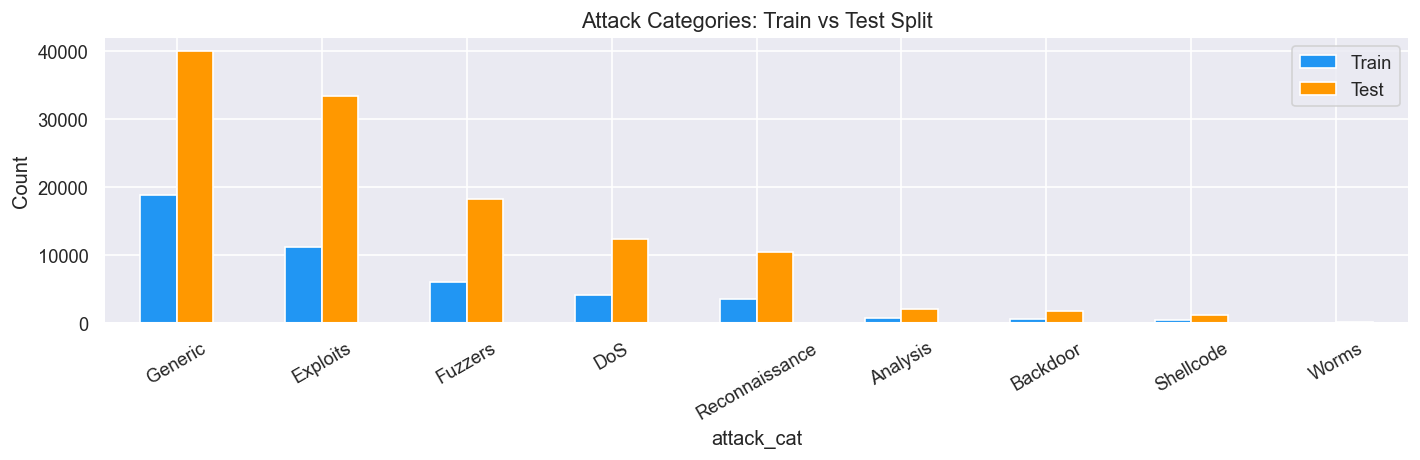

                Train   Test
attack_cat                  
Generic         18871  40000
Exploits        11132  33393
Fuzzers          6062  18184
DoS              4089  12264
Reconnaissance   3496  10491
Analysis          677   2000
Backdoor          583   1746
Shellcode         378   1133
Worms              44    130


In [24]:
# Train vs Test split per category
train_cat = train_df[train_df['label']==1]['attack_cat'].str.strip().value_counts().rename('Train')
test_cat  = test_df[test_df['label']==1]['attack_cat'].str.strip().value_counts().rename('Test')
cat_df = pd.concat([train_cat, test_cat], axis=1).fillna(0).astype(int)

cat_df.plot(kind='bar', figsize=(12, 4), color=['#2196F3', '#FF9800'],
            edgecolor='white', rot=30)
plt.title('Attack Categories: Train vs Test Split')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(cat_df)

## 5. Feature Statistics & Correlation

In [25]:
num_cols = train_df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['id', 'label']]
print(f'Numeric feature count: {len(num_cols)}')
train_df[num_cols].describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

Numeric feature count: 39


,count,mean,std,min,25%,50%,75%,max
dur,82332.000000,1.006756,4.710444,0.000000,0.000008,0.014138,0.719360,59.999989
spkts,82332.000000,18.666472,133.916353,1.000000,2.000000,6.000000,12.000000,10646.000000
dpkts,82332.000000,17.545936,115.574086,0.000000,0.000000,2.000000,10.000000,11018.000000
sbytes,82332.000000,7993.908165,171642.261880,24.000000,114.000000,534.000000,1280.000000,14355774.000000
dbytes,82332.000000,13233.785563,151471.456091,0.000000,0.000000,178.000000,956.000000,14657531.000000
rate,82332.000000,82410.886739,148620.367041,0.000000,28.606114,2650.176667,111111.107200,1000000.003000
sttl,82332.000000,180.967667,101.513358,0.000000,62.000000,254.000000,254.000000,255.000000
dttl,82332.000000,95.713003,116.667722,0.000000,0.000000,29.000000,252.000000,253.000000
sload,82332.000000,64549016.914059,179861832.630003,0.000000,11202.466797,577003.218750,65142856.000000,5268000256.000000
dload,82332.000000,630546.959000,2393000.555646,0.000000,0.000000,2112.951416,15858.082275,20821108.000000


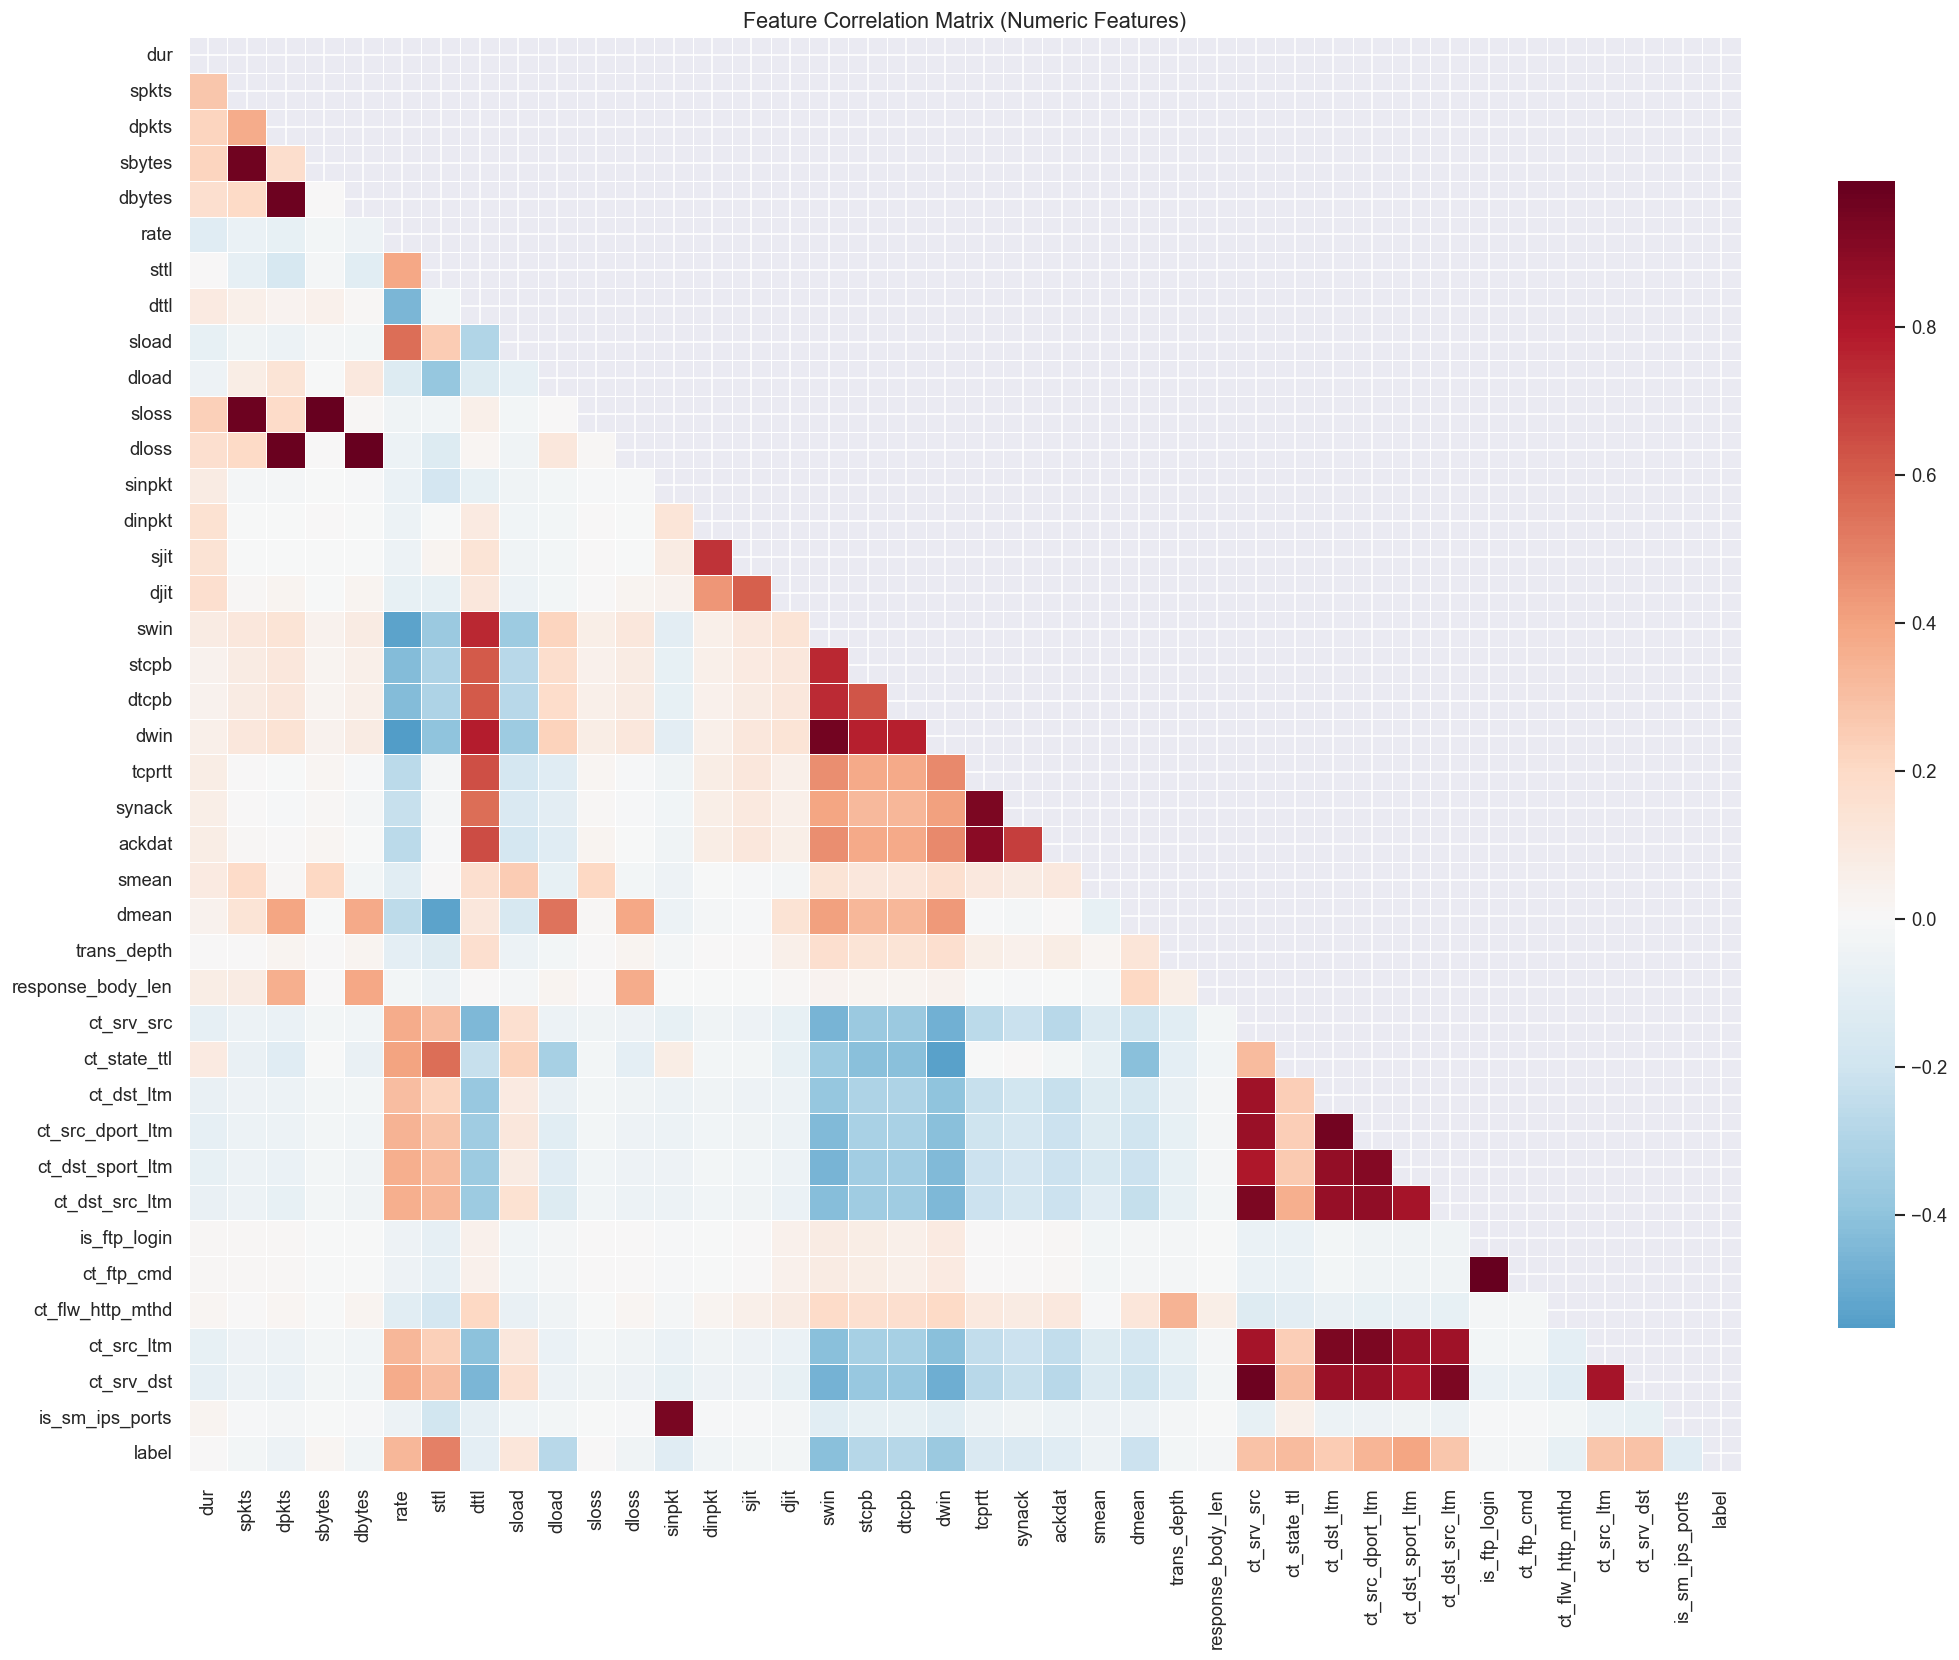

In [26]:
# Correlation heatmap (numeric features only)
corr = train_df[num_cols + ['label']].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.3,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()

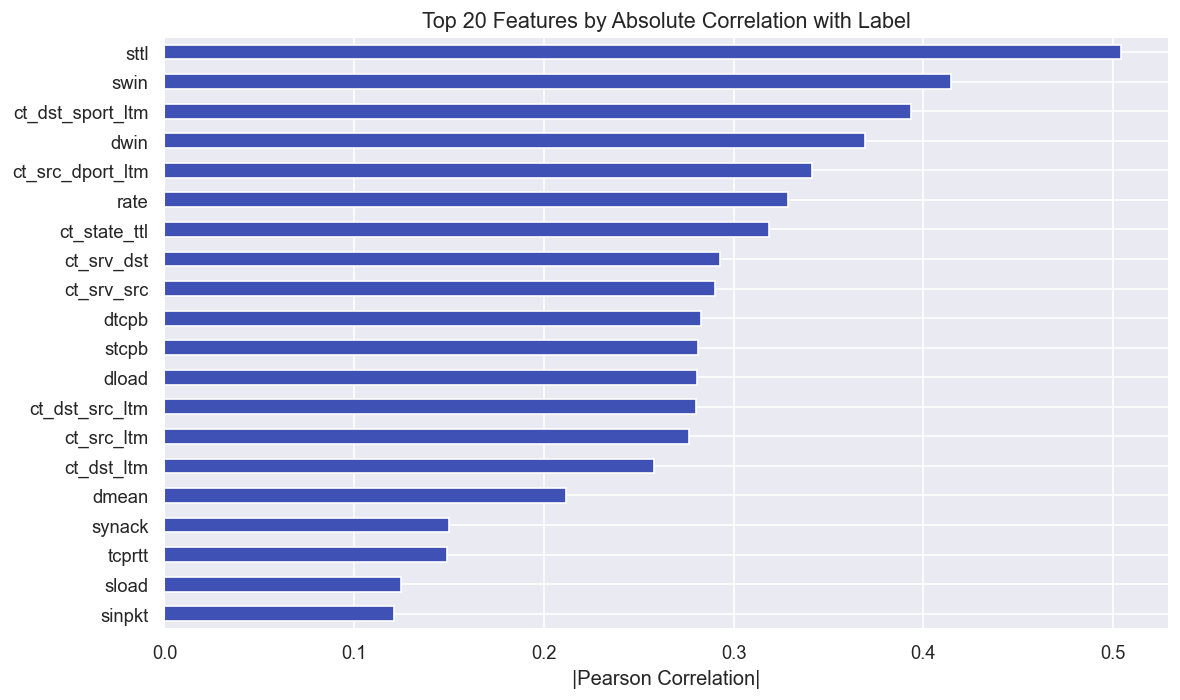

In [27]:
# Top features correlated with the binary label
label_corr = corr['label'].drop('label').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
label_corr.head(20).plot(kind='barh', color='#3F51B5', edgecolor='white')
plt.gca().invert_yaxis()
plt.title('Top 20 Features by Absolute Correlation with Label')
plt.xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.show()

## 6. Protocol / Service / State Analysis

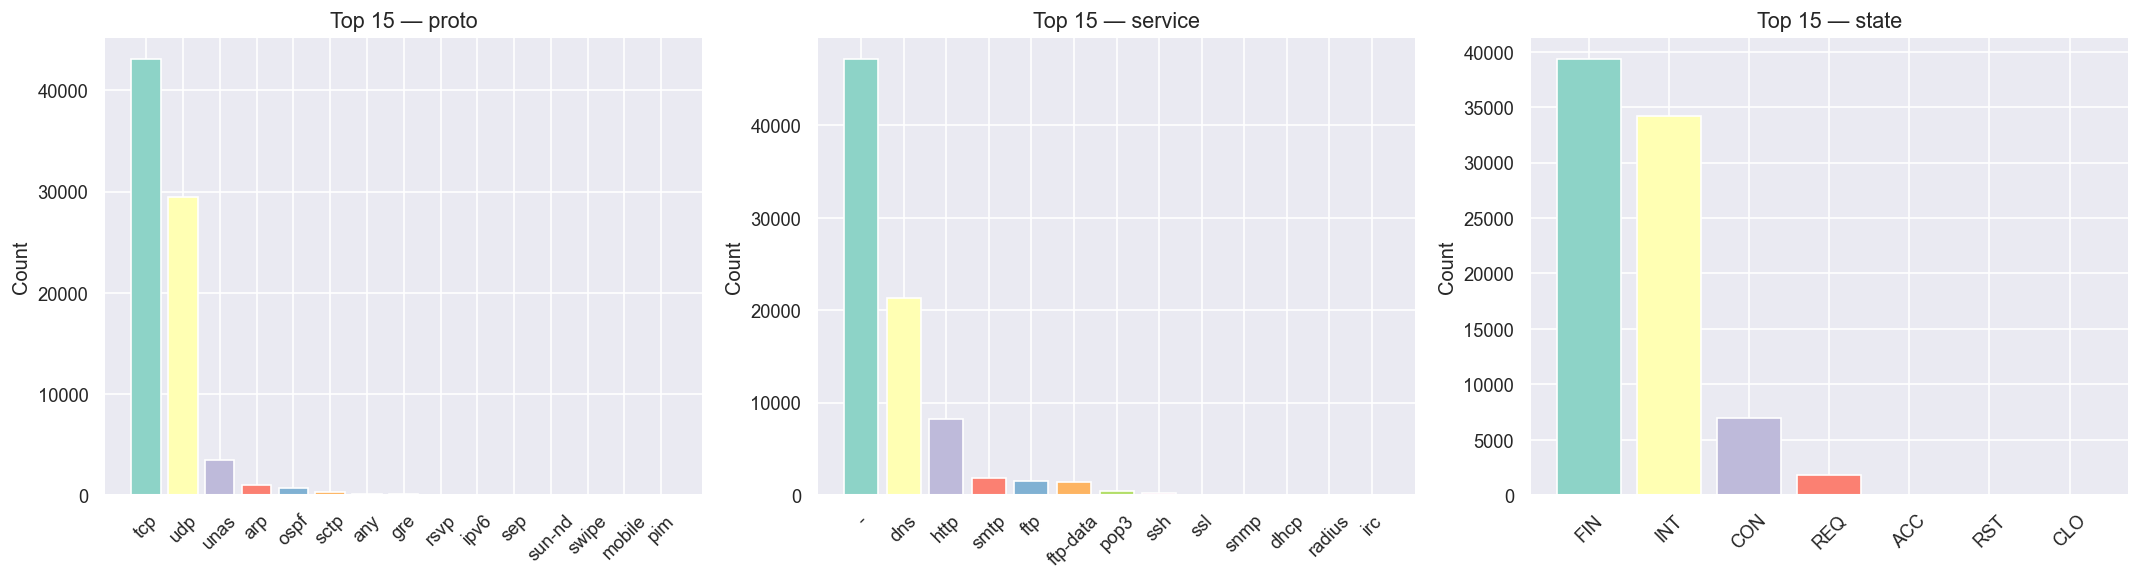

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['proto', 'service', 'state']):
    vc = train_df[col].str.strip().value_counts().head(15)
    ax.bar(vc.index, vc.values,
           color=sns.color_palette('Set3', len(vc)), edgecolor='white')
    ax.set_title(f'Top 15 — {col}')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

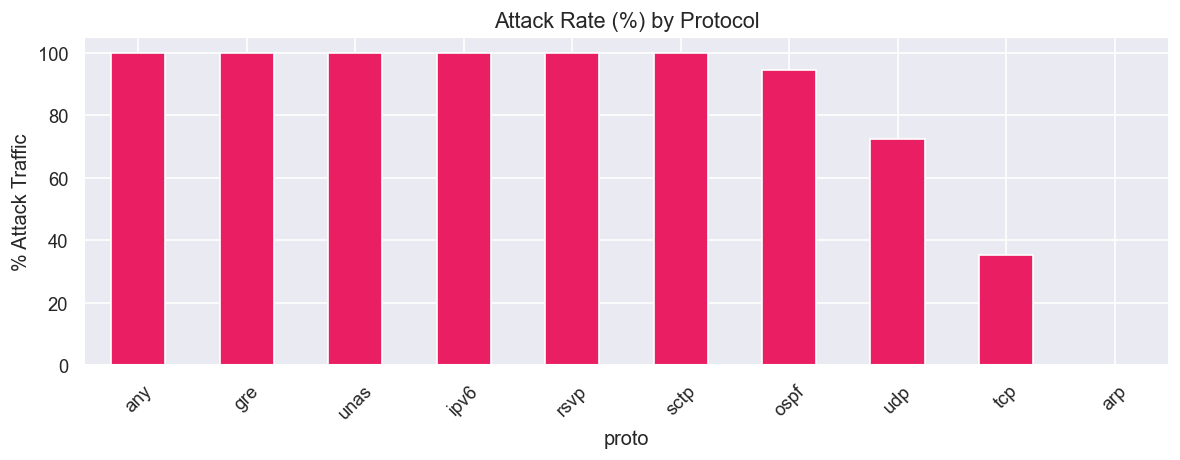

In [29]:
# Attack rate per protocol (top protocols)
top_proto = train_df['proto'].str.strip().value_counts().head(10).index
proto_attack = (
    train_df[train_df['proto'].str.strip().isin(top_proto)]
    .groupby('proto')['label'].mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
proto_attack.plot(kind='bar', color='#E91E63', edgecolor='white')
plt.title('Attack Rate (%) by Protocol')
plt.ylabel('% Attack Traffic')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Distribution Plots — Key Features

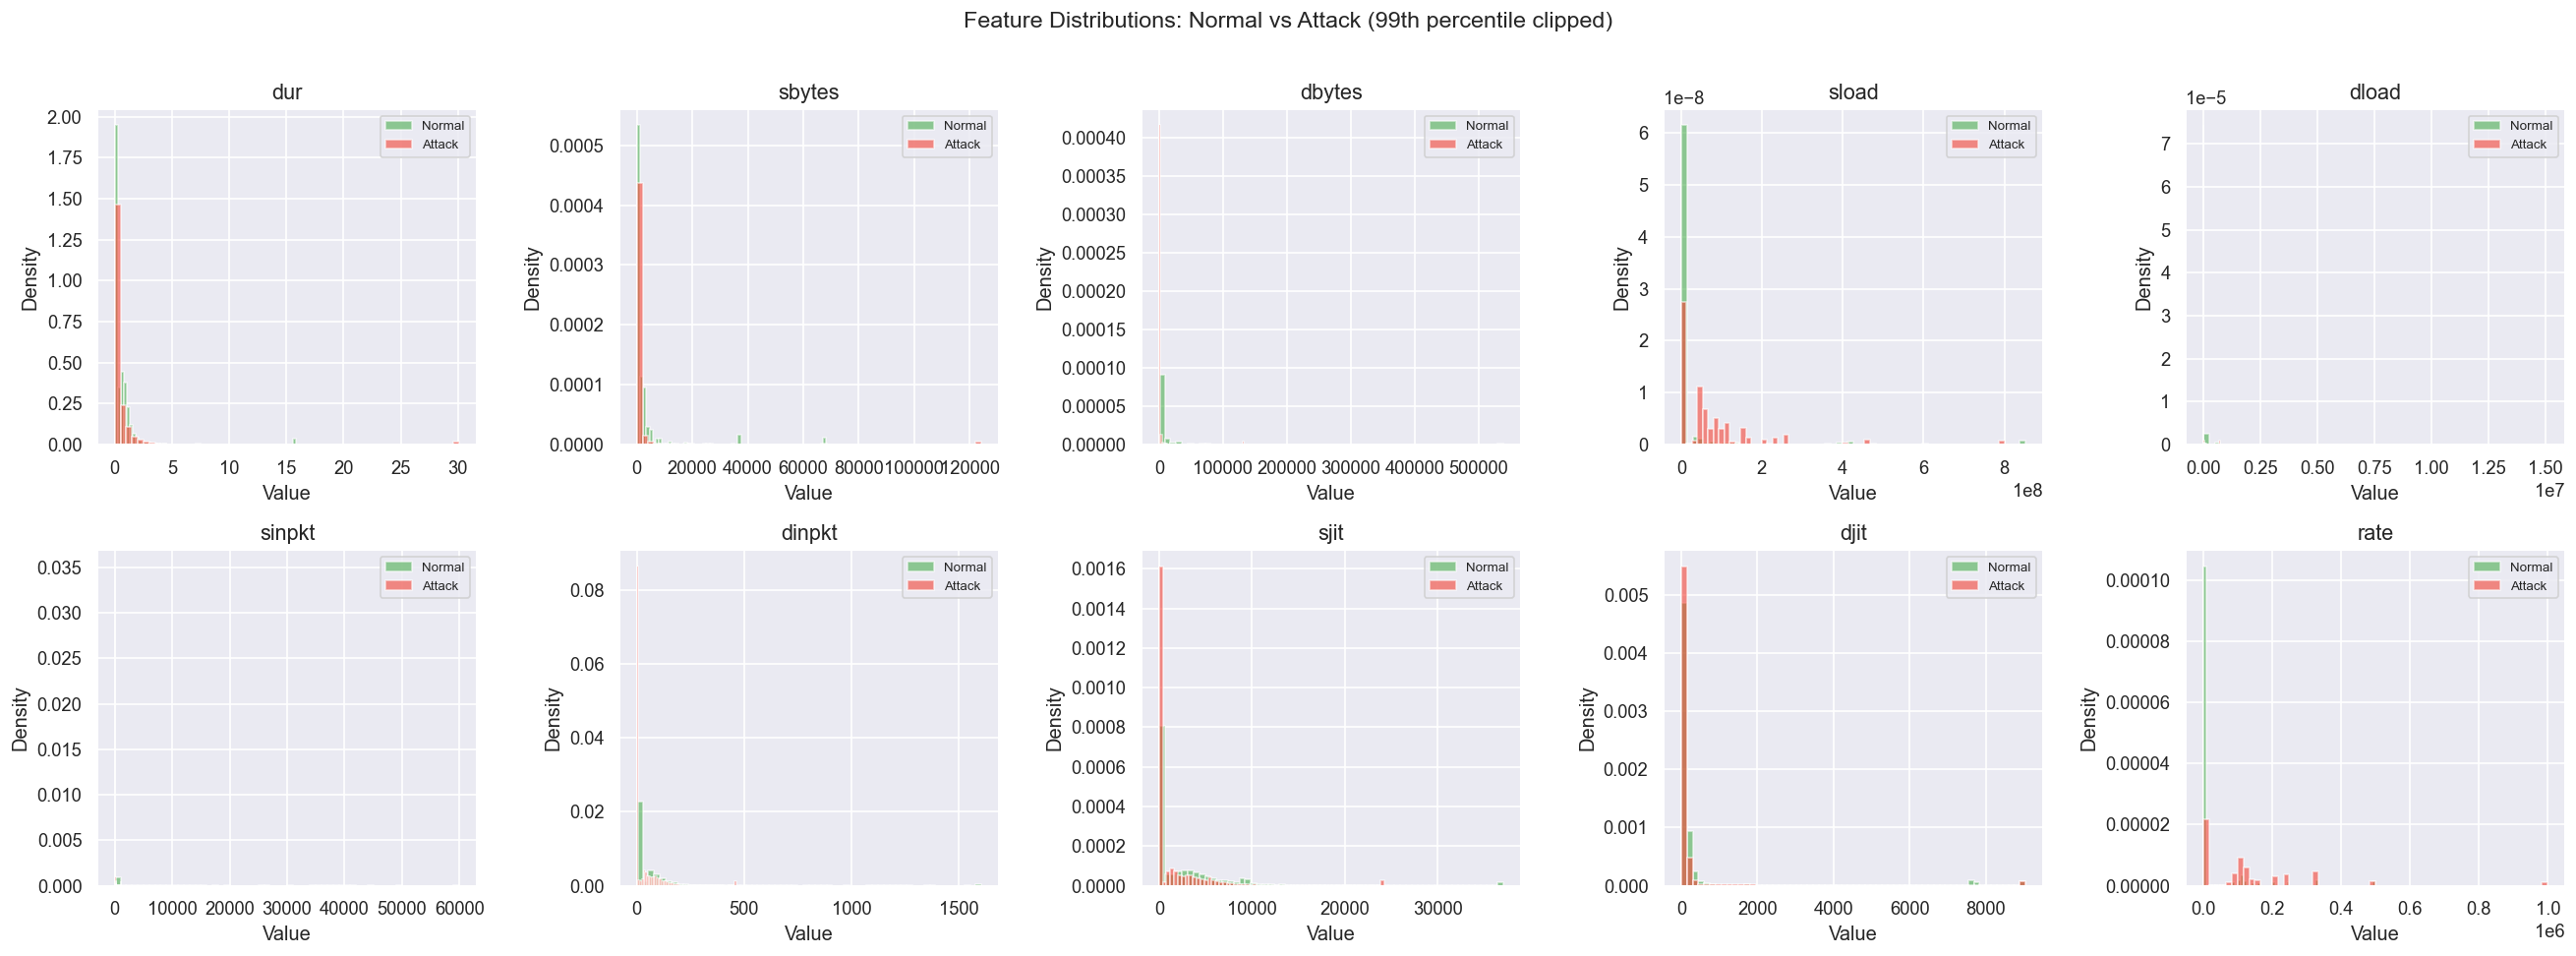

In [30]:
key_features = ['dur', 'sbytes', 'dbytes', 'sload', 'dload',
                'sinpkt', 'dinpkt', 'sjit', 'djit', 'rate']

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

normal = train_df[train_df['label'] == 0]
attack = train_df[train_df['label'] == 1]

for ax, feat in zip(axes, key_features):
    data_n = normal[feat].clip(upper=normal[feat].quantile(0.99))
    data_a = attack[feat].clip(upper=attack[feat].quantile(0.99))
    ax.hist(data_n, bins=60, alpha=0.6, label='Normal', density=True, color='#4CAF50')
    ax.hist(data_a, bins=60, alpha=0.6, label='Attack', density=True, color='#F44336')
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Normal vs Attack (99th percentile clipped)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

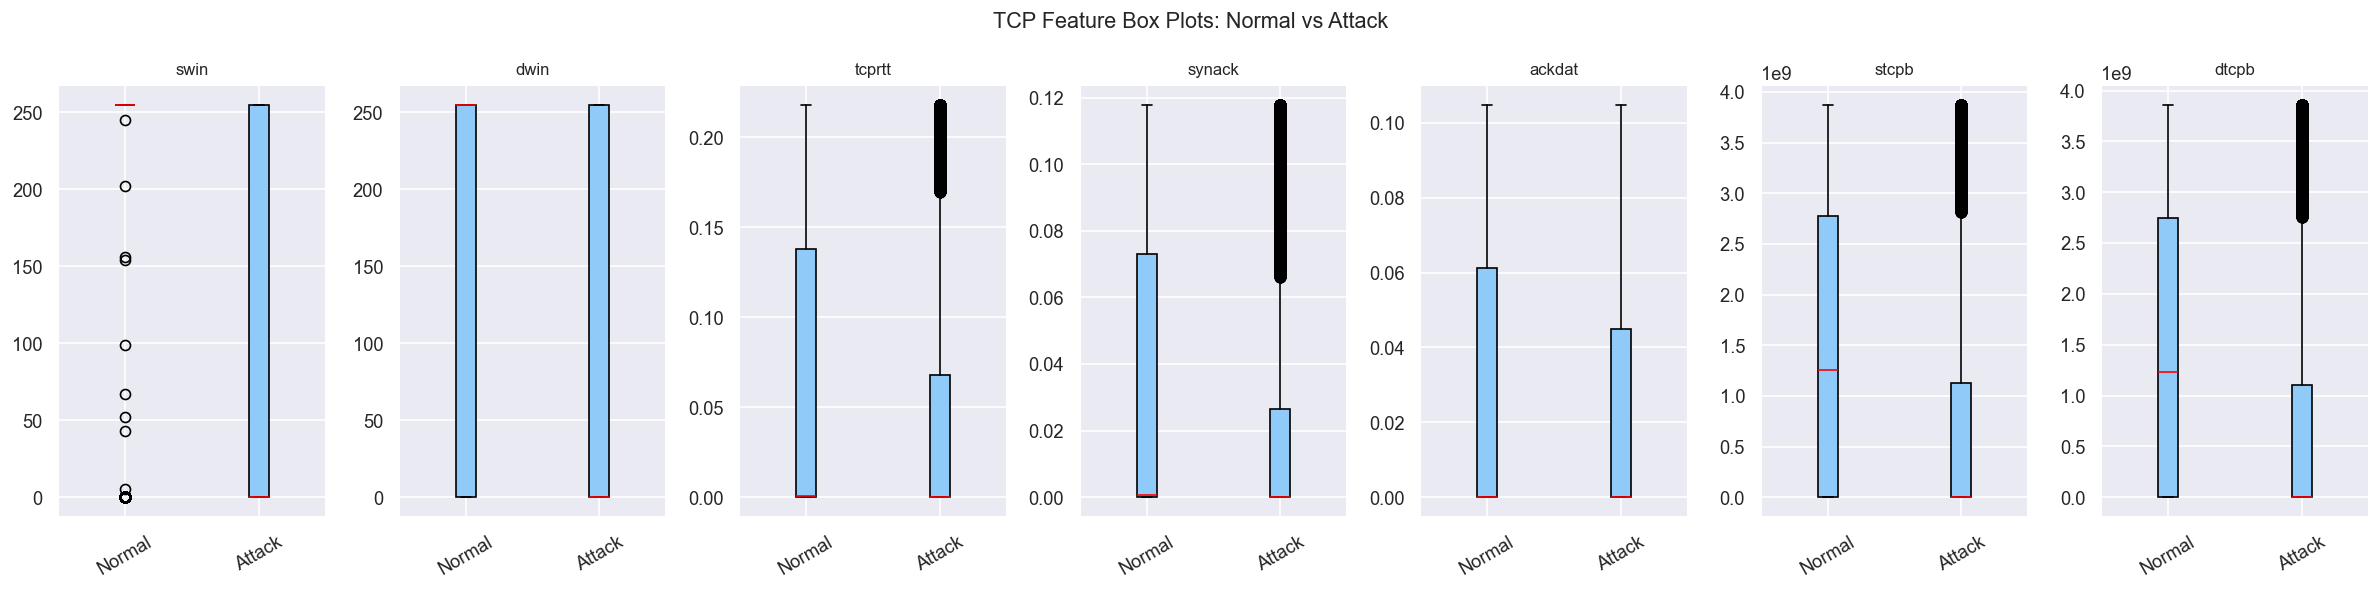

In [31]:
# Box plots for TCP-specific features
tcp_features = ['swin', 'dwin', 'tcprtt', 'synack', 'ackdat', 'stcpb', 'dtcpb']

fig, axes = plt.subplots(1, len(tcp_features), figsize=(20, 5))
for ax, feat in zip(axes, tcp_features):
    data = [train_df[train_df['label']==0][feat].clip(upper=train_df[feat].quantile(0.95)),
            train_df[train_df['label']==1][feat].clip(upper=train_df[feat].quantile(0.95))]
    ax.boxplot(data, labels=['Normal', 'Attack'],
               patch_artist=True,
               boxprops=dict(facecolor='#90CAF9'),
               medianprops=dict(color='red'))
    ax.set_title(feat, fontsize=10)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('TCP Feature Box Plots: Normal vs Attack', fontsize=13)
plt.tight_layout()
plt.show()

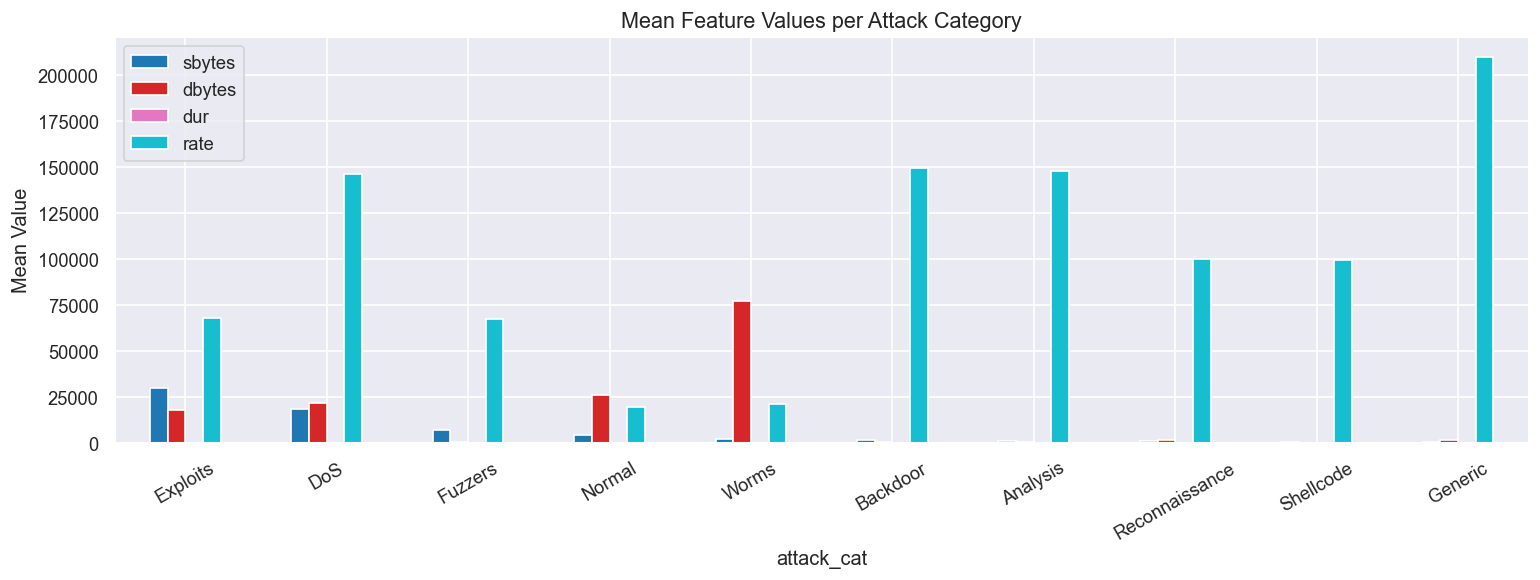

In [32]:
# Mean sbytes per attack category — quick profiling
cat_feat = (
    full_df.groupby('attack_cat')[['sbytes', 'dbytes', 'dur', 'rate']]
    .mean()
    .sort_values('sbytes', ascending=False)
)

cat_feat.plot(kind='bar', figsize=(13, 5), colormap='tab10', edgecolor='white')
plt.title('Mean Feature Values per Attack Category')
plt.ylabel('Mean Value')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. Preprocessing
- Drop `id` column (identifier, not a feature)
- Label-encode categorical columns: `proto`, `service`, `state`
- Drop `attack_cat` (not needed for binary classification)
- Standard-scale all numeric features

In [33]:
CAT_COLS = ['proto', 'service', 'state']
DROP_COLS = ['id', 'attack_cat']
TARGET = 'label'

def preprocess(df, encoders=None, fit=True):
    df = df.drop(columns=DROP_COLS, errors='ignore').copy()
    df[CAT_COLS] = df[CAT_COLS].apply(lambda c: c.str.strip())
    
    if fit:
        encoders = {col: LabelEncoder() for col in CAT_COLS}
        for col in CAT_COLS:
            df[col] = encoders[col].fit_transform(df[col].astype(str))
    else:
        for col in CAT_COLS:
            # Handle unseen labels gracefully
            le = encoders[col]
            df[col] = df[col].astype(str).map(
                lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
            )
    return df, encoders

train_proc, encoders = preprocess(train_df, fit=True)
test_proc,  _        = preprocess(test_df,  encoders=encoders, fit=False)

X_train = train_proc.drop(columns=[TARGET])
y_train = train_proc[TARGET]
X_test  = test_proc.drop(columns=[TARGET])
y_test  = test_proc[TARGET]

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Preprocessing complete ✓')

X_train: (82332, 42), X_test: (175341, 42)
Preprocessing complete ✓


## 9. ANOVA Feature Selection
The paper (Musthafa et al., 2025) uses ANOVA F-test to select the **top 36 features** from the UNSW-NB15 feature set, reducing noise and improving model efficiency.

In [34]:
N_FEATURES = 36   # as used in the reference paper

f_scores, p_values = f_classif(X_train_scaled, y_train)

anova_df = pd.DataFrame({
    'feature': X_train.columns,
    'f_score': f_scores,
    'p_value': p_values
}).sort_values('f_score', ascending=False)

selected_features = anova_df.head(N_FEATURES)['feature'].tolist()

print(f'Selected {N_FEATURES} features via ANOVA F-test:')
print(selected_features)

Selected 36 features via ANOVA F-test:
['sttl', 'state', 'swin', 'ct_dst_sport_ltm', 'dwin', 'ct_src_dport_ltm', 'rate', 'ct_state_ttl', 'ct_srv_dst', 'ct_srv_src', 'dtcpb', 'stcpb', 'dload', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_dst_ltm', 'dmean', 'synack', 'tcprtt', 'service', 'sload', 'sinpkt', 'ackdat', 'is_sm_ips_ports', 'dttl', 'ct_flw_http_mthd', 'dpkts', 'smean', 'dloss', 'dinpkt', 'dbytes', 'spkts', 'sjit', 'djit', 'trans_depth', 'sbytes']


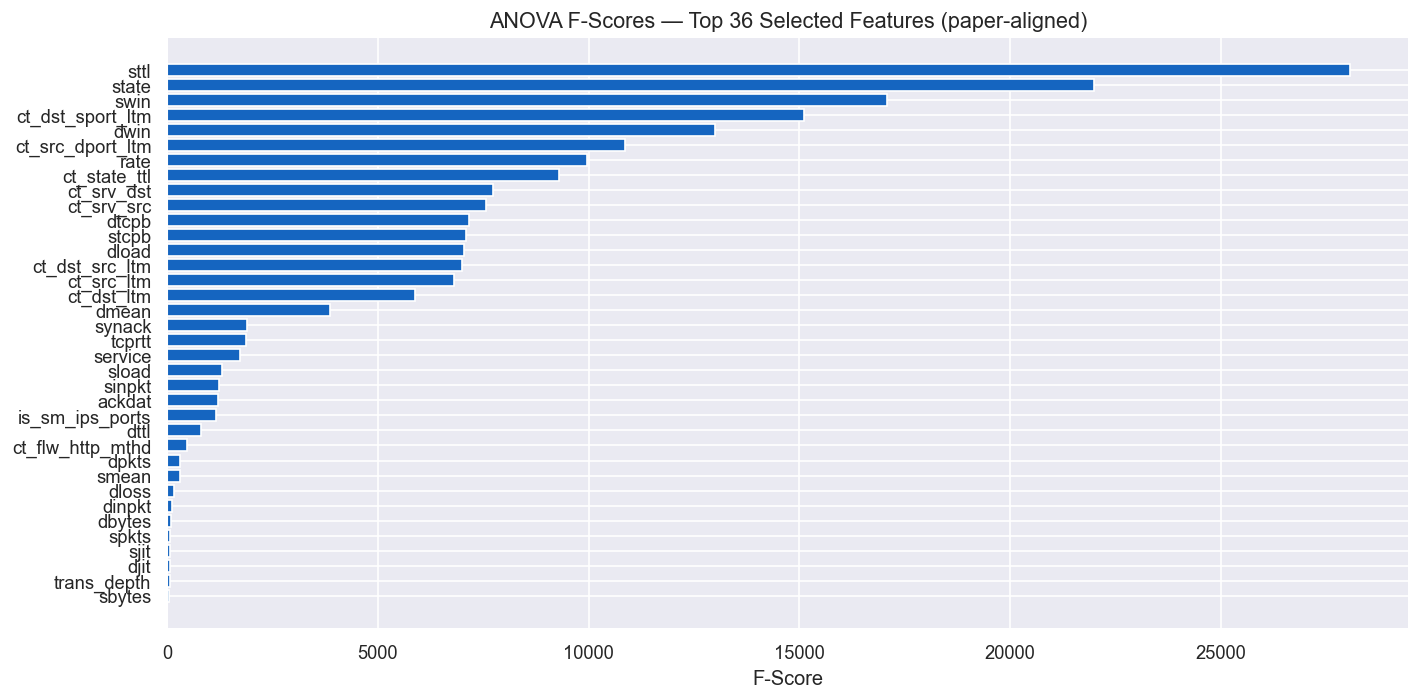


Eliminated 6 features: ['ct_ftp_cmd', 'response_body_len', 'is_ftp_login', 'sloss', 'proto', 'dur']


In [35]:
plt.figure(figsize=(12, 6))
top = anova_df.head(N_FEATURES)
colors = ['#E53935' if f in selected_features else '#90CAF9' for f in anova_df.head(N_FEATURES+5)['feature']]
plt.barh(top['feature'][::-1], top['f_score'][::-1],
         color='#1565C0', edgecolor='white')
plt.title(f'ANOVA F-Scores — Top {N_FEATURES} Selected Features (paper-aligned)')
plt.xlabel('F-Score')
plt.tight_layout()
plt.show()

# Eliminated features
eliminated = anova_df.tail(len(anova_df) - N_FEATURES)['feature'].tolist()
print(f'\nEliminated {len(eliminated)} features: {eliminated}')

In [36]:
# Apply ANOVA selection
X_train_sel = pd.DataFrame(X_train_scaled, columns=X_train.columns)[selected_features].values
X_test_sel  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)[selected_features].values

print(f'X_train_sel: {X_train_sel.shape}')
print(f'X_test_sel : {X_test_sel.shape}')

X_train_sel: (82332, 36)
X_test_sel : (175341, 36)


## 10. PCA Visualisation

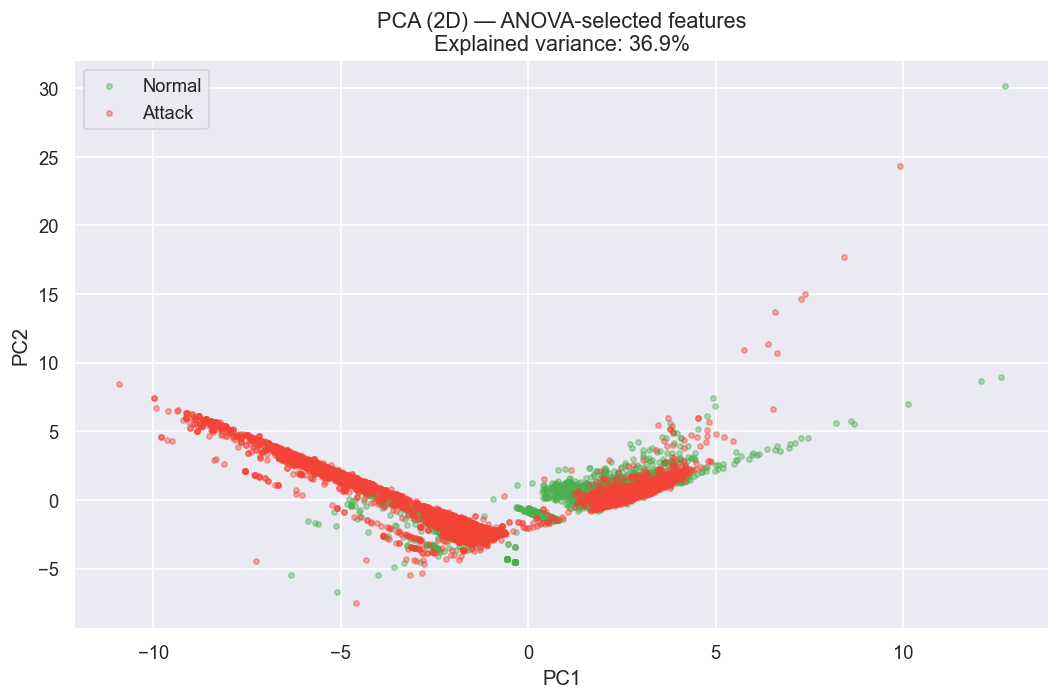

In [37]:
pca = PCA(n_components=2, random_state=SEED)
# Use a sample for speed
sample_idx = np.random.choice(len(X_train_sel), size=10000, replace=False)
X_pca = pca.fit_transform(X_train_sel[sample_idx])
y_pca = y_train.values[sample_idx]

plt.figure(figsize=(9, 6))
for label, color, name in [(0, '#4CAF50', 'Normal'), (1, '#F44336', 'Attack')]:
    mask = y_pca == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, alpha=0.4, s=10, label=name)
plt.title(f'PCA (2D) — ANOVA-selected features\n'
          f'Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

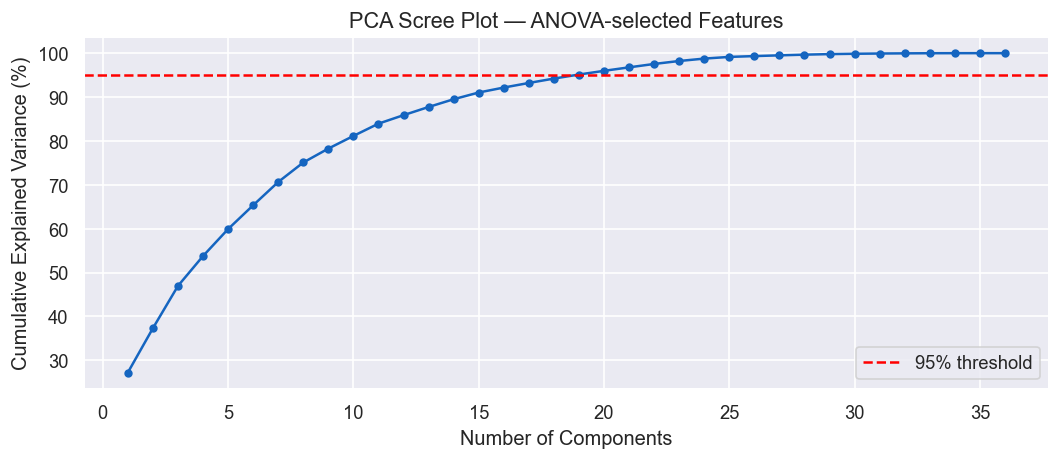

In [38]:
pca_full = PCA(random_state=SEED).fit(X_train_sel)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=4,
         color='#1565C0')
plt.axhline(95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Scree Plot — ANOVA-selected Features')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Random Forest Baseline + Feature Importances

In [39]:
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train_sel, y_train)

y_pred_rf = rf.predict(X_test_sel)
y_prob_rf = rf.predict_proba(X_test_sel)[:, 1]

print('=== Random Forest Results (ANOVA features) ===')
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Attack']))
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf)*100:.4f}%')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}')

=== Random Forest Results (ANOVA features) ===
              precision    recall  f1-score   support

      Normal       0.77      0.98      0.86     56000
      Attack       0.99      0.86      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.90    175341

Accuracy : 89.9858%
ROC-AUC  : 0.9812


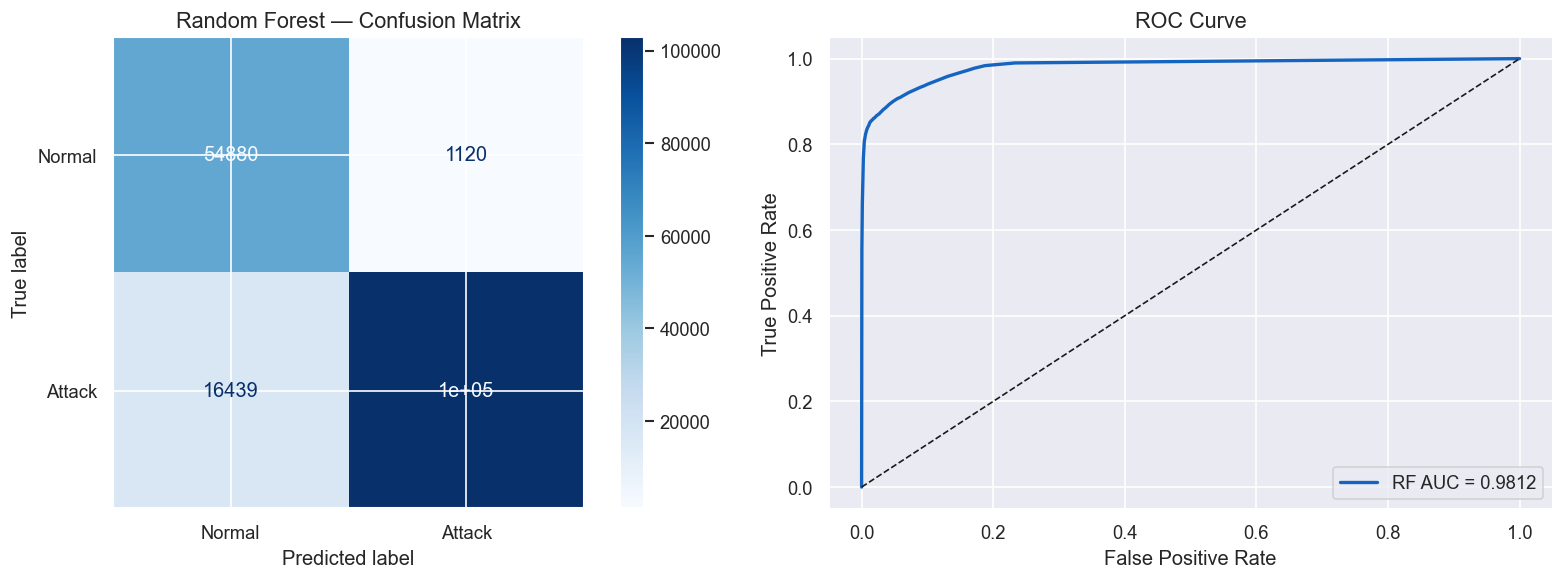

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Random Forest — Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_val = roc_auc_score(y_test, y_prob_rf)
axes[1].plot(fpr, tpr, color='#1565C0', lw=2, label=f'RF AUC = {auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

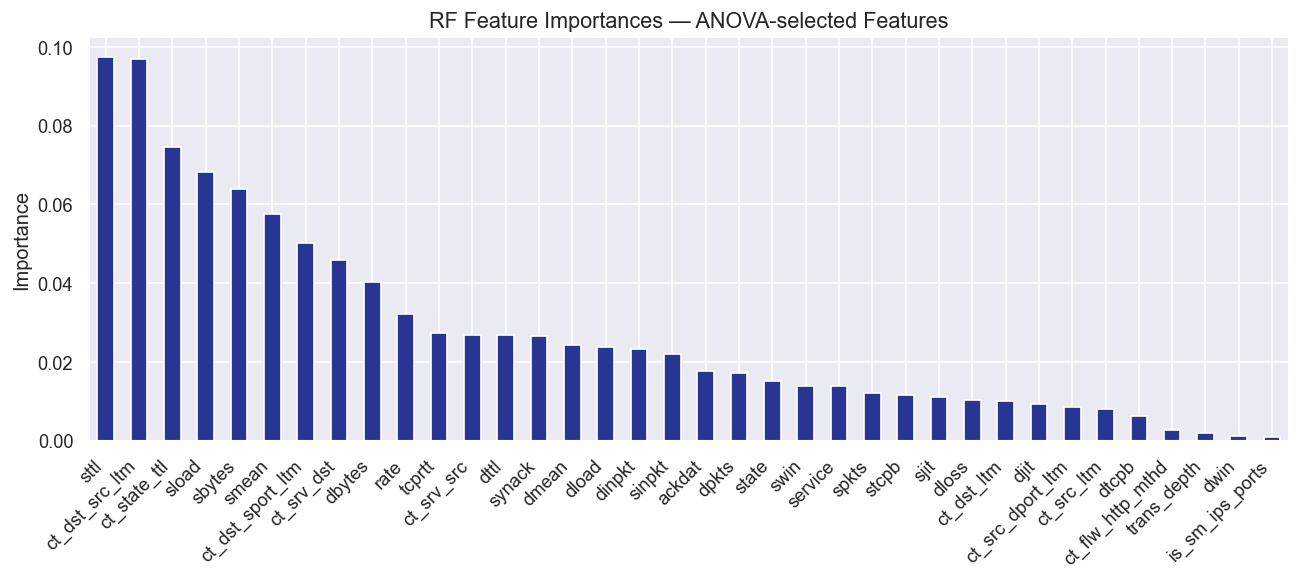

In [41]:
importances = pd.Series(rf.feature_importances_, index=selected_features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(11, 5))
importances.plot(kind='bar', color='#283593', edgecolor='white')
plt.title('RF Feature Importances — ANOVA-selected Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 12. Stacked LSTM Binary Classifier (PyTorch)
Reproduces the core architecture from the reference paper:
- 2-layer stacked LSTM
- Dropout regularisation
- Binary output (Normal / Attack)
- ANOVA-selected 36 features as input

> **Note:** For resource-constrained deployment (Raspberry Pi), the paper further applies pruning + INT8 quantization via TFLite. That step is omitted here (requires TensorFlow); the PyTorch model below is the full-precision equivalent.

In [42]:
class StackedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.bn   = nn.BatchNorm1d(hidden_size)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len=1, features)
        out, _ = self.lstm(x)
        out = out[:, -1, :]          # last time step
        out = self.bn(out)
        out = self.drop(out)
        return self.fc(out).squeeze(1)

INPUT_SIZE  = X_train_sel.shape[1]   # 36
model = StackedLSTM(input_size=INPUT_SIZE).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

StackedLSTM(
  (lstm): LSTM(36, 128, num_layers=2, batch_first=True, dropout=0.3)
  (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 217,473


In [43]:
BATCH_SIZE = 1024
EPOCHS     = 15
LR         = 1e-3

# Reshape: (N, 1, features) — treating each record as a single time-step
X_tr = torch.tensor(X_train_sel, dtype=torch.float32).unsqueeze(1)
y_tr = torch.tensor(y_train.values, dtype=torch.float32)
X_te = torch.tensor(X_test_sel,  dtype=torch.float32).unsqueeze(1)
y_te = torch.tensor(y_test.values,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr, y_tr),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_te, y_te),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}, Test batches: {len(test_loader)}')

Train batches: 81, Test batches: 172


In [44]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * len(yb)
        preds = (torch.sigmoid(logits) > 0.5).float()
        t_correct += (preds == yb).sum().item()
        t_total   += len(yb)

    # ── Validate ──
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            v_loss += criterion(logits, yb).item() * len(yb)
            preds = (torch.sigmoid(logits) > 0.5).float()
            v_correct += (preds == yb).sum().item()
            v_total   += len(yb)

    t_loss /= t_total; v_loss /= v_total
    t_acc   = t_correct / t_total * 100
    v_acc   = v_correct / v_total * 100

    train_losses.append(t_loss); val_losses.append(v_loss)
    train_accs.append(t_acc);   val_accs.append(v_acc)
    scheduler.step(v_loss)

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {t_loss:.4f}, Acc: {t_acc:.2f}% | '
          f'Val Loss: {v_loss:.4f}, Acc: {v_acc:.2f}%')

Epoch 01/15 | Train Loss: 0.3192, Acc: 85.00% | Val Loss: 0.2700, Acc: 88.29%
Epoch 02/15 | Train Loss: 0.2340, Acc: 89.65% | Val Loss: 0.2954, Acc: 88.08%
Epoch 03/15 | Train Loss: 0.2107, Acc: 90.99% | Val Loss: 0.2953, Acc: 88.33%
Epoch 04/15 | Train Loss: 0.1938, Acc: 91.77% | Val Loss: 0.3085, Acc: 88.00%
Epoch 05/15 | Train Loss: 0.1833, Acc: 92.25% | Val Loss: 0.2833, Acc: 89.05%
Epoch 06/15 | Train Loss: 0.1731, Acc: 92.92% | Val Loss: 0.3017, Acc: 88.50%
Epoch 07/15 | Train Loss: 0.1684, Acc: 93.15% | Val Loss: 0.3299, Acc: 87.45%
Epoch 08/15 | Train Loss: 0.1654, Acc: 93.27% | Val Loss: 0.2861, Acc: 89.37%
Epoch 09/15 | Train Loss: 0.1608, Acc: 93.46% | Val Loss: 0.3278, Acc: 87.28%
Epoch 10/15 | Train Loss: 0.1587, Acc: 93.63% | Val Loss: 0.3247, Acc: 87.86%
Epoch 11/15 | Train Loss: 0.1575, Acc: 93.63% | Val Loss: 0.3174, Acc: 88.16%
Epoch 12/15 | Train Loss: 0.1550, Acc: 93.77% | Val Loss: 0.3272, Acc: 87.71%
Epoch 13/15 | Train Loss: 0.1540, Acc: 93.76% | Val Loss: 0.3121

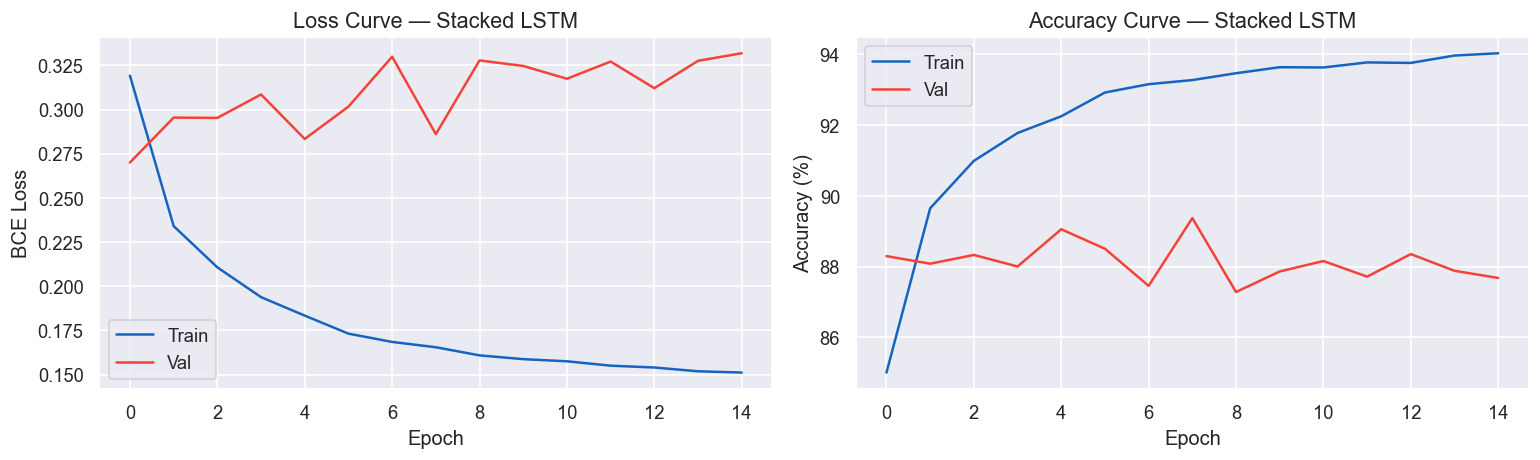

Final Train Acc: 94.0291%
Final Val   Acc: 87.6760%
Overfitting gap: 6.3530%


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses, label='Train', color='#1565C0')
axes[0].plot(val_losses,   label='Val',   color='#F44336')
axes[0].set_title('Loss Curve — Stacked LSTM')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend()

axes[1].plot(train_accs, label='Train', color='#1565C0')
axes[1].plot(val_accs,   label='Val',   color='#F44336')
axes[1].set_title('Accuracy Curve — Stacked LSTM')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

overfitting = train_accs[-1] - val_accs[-1]
print(f'Final Train Acc: {train_accs[-1]:.4f}%')
print(f'Final Val   Acc: {val_accs[-1]:.4f}%')
print(f'Overfitting gap: {overfitting:.4f}%')

## 13. Final Evaluation & Summary

In [46]:
model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        logits = model(Xb.to(device))
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs > 0.5).astype(int)
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(yb.numpy().astype(int))

print('=== Stacked LSTM — Final Test Results ===')
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Attack']))
acc  = accuracy_score(all_labels, all_preds) * 100
auc  = roc_auc_score(all_labels, all_probs)
print(f'Accuracy : {acc:.4f}%')
print(f'ROC-AUC  : {auc:.4f}')

=== Stacked LSTM — Final Test Results ===
              precision    recall  f1-score   support

      Normal       0.73      0.97      0.83     56000
      Attack       0.98      0.83      0.90    119341

    accuracy                           0.88    175341
   macro avg       0.86      0.90      0.87    175341
weighted avg       0.90      0.88      0.88    175341

Accuracy : 87.6760%
ROC-AUC  : 0.9777


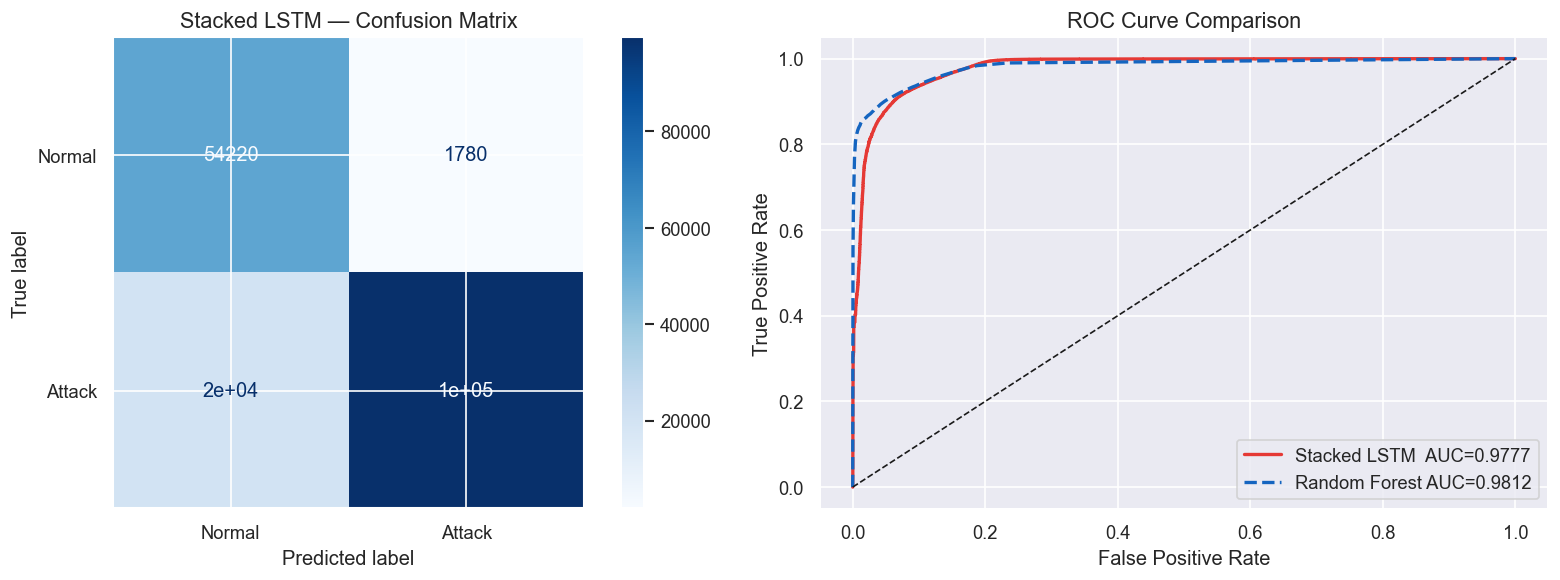

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Stacked LSTM — Confusion Matrix')

# ROC
fpr_l, tpr_l, _ = roc_curve(all_labels, all_probs)
fpr_r, tpr_r, _ = roc_curve(y_test, y_prob_rf)
axes[1].plot(fpr_l, tpr_l, color='#E53935', lw=2,
             label=f'Stacked LSTM  AUC={roc_auc_score(all_labels, all_probs):.4f}')
axes[1].plot(fpr_r, tpr_r, color='#1565C0', lw=2, linestyle='--',
             label=f'Random Forest AUC={roc_auc_score(y_test, y_prob_rf):.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

In [48]:
summary = pd.DataFrame({
    'Model': ['Random Forest (baseline)', 'Stacked LSTM (PyTorch)', 'Paper — Stacked LSTM+ANOVA (TF)'],
    'Accuracy (%)': [
        round(accuracy_score(y_test, y_pred_rf)*100, 4),
        round(acc, 4),
        97.46
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_prob_rf), 4),
        round(auc, 4),
        0.9728
    ],
    'Features Used': [N_FEATURES, N_FEATURES, 36],
    'Notes': [
        'sklearn RF, n=100',
        f'2-layer LSTM, {EPOCHS} epochs, PyTorch',
        'Musthafa et al. 2025 (TensorFlow, full training)'
    ]
})

print('=== SUMMARY ===')
summary.style.highlight_max(subset=['Accuracy (%)'], color='lightgreen')

=== SUMMARY ===


,Model,Accuracy (%),ROC-AUC,Features Used,Notes
0,Random Forest (baseline),89.985800,0.981200,36,"sklearn RF, n=100"
1,Stacked LSTM (PyTorch),87.676000,0.977700,36,"2-layer LSTM, 15 epochs, PyTorch"
2,Paper — Stacked LSTM+ANOVA (TF),97.460000,0.972800,36,"Musthafa et al. 2025 (TensorFlow, full training)"


In [49]:
print("""
=== NEXT STEPS (as suggested by Musthafa et al. 2025) ===

1. Model Compression (for edge deployment):
   - Convert to TensorFlow Lite (TFLite)
   - Apply Post-Training Quantization (INT8)
   - Apply prune_low_magnitude with PolynomialDecay schedule
   - Target: ~90% size reduction with <0.21% accuracy drop

2. Real-Time Evaluation:
   - Set up Apache Kafka producer-consumer pipeline
   - Stream UNSW-NB15 records as simulated network traffic
   - Deploy optimized model on Raspberry Pi 3B+
   - Test with 1, 2, 3 concurrent Kafka producers

3. Future Research Directions:
   - Federated Learning for privacy-preserving IDS
   - Blockchain-based decentralized trust management
   - Online/incremental learning for adaptive threat detection
   - Transfer learning across datasets (NSL-KDD, CICIoT2023, BoT-IoT)
   - Energy consumption profiling on battery-powered devices
""")


=== NEXT STEPS (as suggested by Musthafa et al. 2025) ===

1. Model Compression (for edge deployment):
   - Convert to TensorFlow Lite (TFLite)
   - Apply Post-Training Quantization (INT8)
   - Apply prune_low_magnitude with PolynomialDecay schedule
   - Target: ~90% size reduction with <0.21% accuracy drop

2. Real-Time Evaluation:
   - Set up Apache Kafka producer-consumer pipeline
   - Stream UNSW-NB15 records as simulated network traffic
   - Deploy optimized model on Raspberry Pi 3B+
   - Test with 1, 2, 3 concurrent Kafka producers

3. Future Research Directions:
   - Federated Learning for privacy-preserving IDS
   - Blockchain-based decentralized trust management
   - Online/incremental learning for adaptive threat detection
   - Transfer learning across datasets (NSL-KDD, CICIoT2023, BoT-IoT)
   - Energy consumption profiling on battery-powered devices

